In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.11.0+cu128'

In [ ]:
#weight and bias
weight = 0.7
bias = 0.3
#create data
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X  + bias
X[:10] ,y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X),len(y)

(50, 50)

In [ ]:
#from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 0)
#len(X_train), len(y_train), len(X_test), len(y_test)

In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)



(40, 40, 10, 10)

In [ ]:
def plot_prediction(train_data = X_train,
                   train_labels = y_train,
                   test_data = X_test,
                   test_labels = y_test,
                   predictions= None) :
    plt.figure(figsize = (10,7))
    plt.scatter(train_data,train_labels, c= 'b',s = 4, label = 'training data')
    plt.scatter(test_data,test_labels, c= 'g',s = 4, label = 'test data')

    if predictions is not None :
        plt.scatter(test_data,predictions, c= 'r',s = 4,label = 'Prediction')

    plt.legend(prop = { 'size': 14})

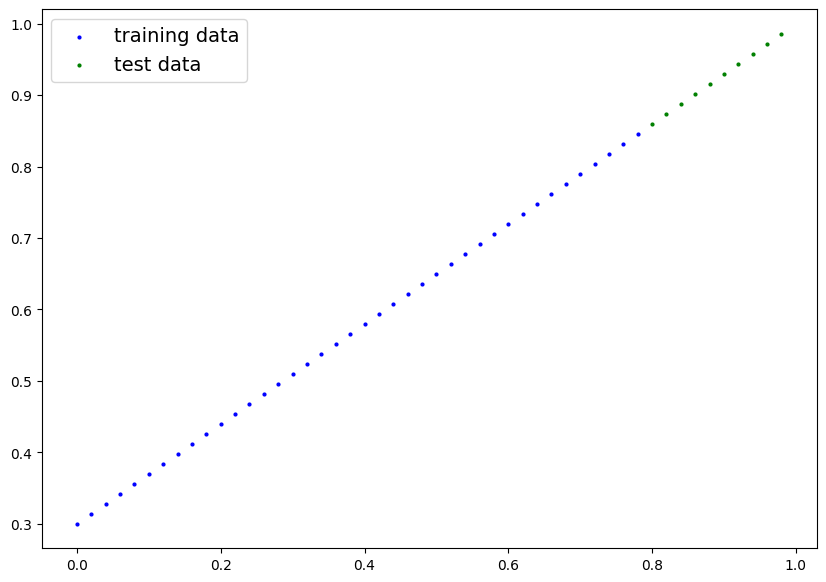

In [ ]:
plot_prediction()

In [ ]:
# our first pytorch model
from torch import nn
class LinearRegressionModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.rand(1,
                                               requires_grad = True,
                                               dtype = torch.float))
        self.bias = nn.Parameter(torch.rand(1,
                                            requires_grad = True,
                                            dtype = torch.float))
    def forward(self,x: torch.Tensor) -> torch.Tensor:
        return self.weights * x  + self.bias

In [ ]:
torch.manual_seed(42)

model_0 = LinearRegressionModule()
list(model_0.parameters())


[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [ ]:
#state of the model
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [ ]:
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [ ]:
y_test


tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

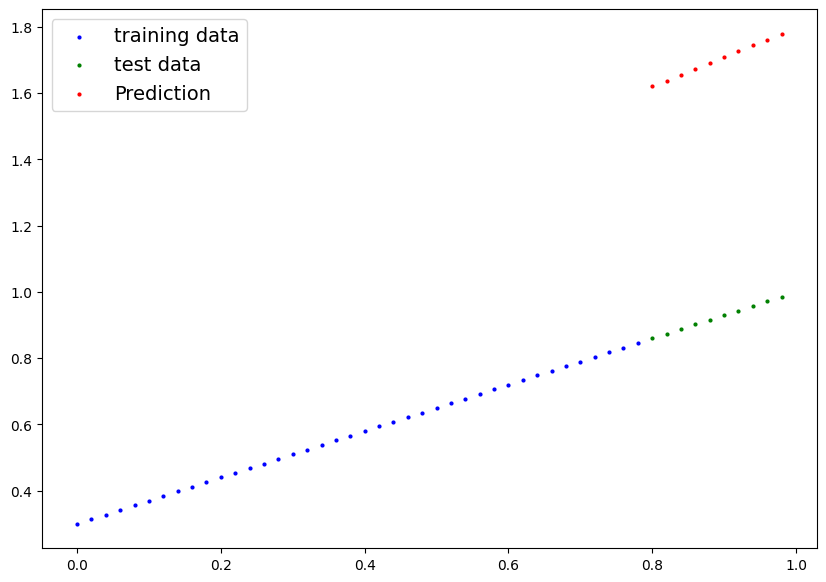

In [ ]:
plot_prediction(predictions = y_preds)

In [ ]:
#3 Train Model
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [ ]:
#creates the loss function
Loss_fn = nn.L1Loss()
#optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),lr = 0.01)

In [ ]:
### Building a training loop in pytorch
# an epoch is one loop through the data..
import numpy as numpy
epochs  = 200

epoch_count = []
train_loss_values = []
test_loss_values = []

#0. Loopthrough the data
for epoch in range(epochs):
  #set the model to training mode
  model_0.train() # train mode in pytorch sets all parmas that require gradients to require gradients

  #1. Forward pass
  y_pred = model_0(X_train)
  #2 calculate the loss
  loss = Loss_fn(y_pred,y_train)
  print(f"Loss : {loss}")
  #3 optimizer zero grad
  optimizer.zero_grad()
  #4 perform backpropgaition on the loss with respect to the parametes of the model
  loss.backward()
  #5 step the optimizer( perform gradient descent)
  optimizer.step()

  #####testing
  model_0.eval() #turns off gradient tracking

  with torch.inference_mode():
    test_pred = model_0(X_test)
    test_loss = Loss_fn(test_pred,y_test)

  #orint out what's happening
  if epoch % 10 == 0 :
    epoch_count.append(epoch)
    train_loss_values.append(loss.detach().numpy())
    test_loss_values.append(test_loss.detach().numpy())
    print(f"Epoch: {epoch} | Loss: {loss} |Test Loss: {test_loss} ")
    #printing the model_dict
    print(model_0.state_dict())

Loss : 0.6860889196395874
Epoch: 0 | Loss: 0.6860889196395874 |Test Loss: 0.7637526988983154 
OrderedDict({'weights': tensor([0.8784]), 'bias': tensor([0.9050])})
Loss : 0.6745679974555969
Loss : 0.6630470156669617
Loss : 0.6515260338783264
Loss : 0.6400049924850464
Loss : 0.6284840703010559
Loss : 0.6169630289077759
Loss : 0.6054420471191406
Loss : 0.5939210653305054
Loss : 0.5824000239372253
Loss : 0.5708791017532349
Epoch: 10 | Loss: 0.5708791017532349 |Test Loss: 0.6290428042411804 
OrderedDict({'weights': tensor([0.8394]), 'bias': tensor([0.8050])})
Loss : 0.5593580603599548
Loss : 0.5478371381759644
Loss : 0.5363161563873291
Loss : 0.5247951149940491
Loss : 0.5132741332054138
Loss : 0.5017532110214233
Loss : 0.4902321696281433
Loss : 0.47871121764183044
Loss : 0.4671902060508728
Loss : 0.45566922426223755
Epoch: 20 | Loss: 0.45566922426223755 |Test Loss: 0.4943329691886902 
OrderedDict({'weights': tensor([0.8004]), 'bias': tensor([0.7050])})
Loss : 0.4441482126712799
Loss : 0.432

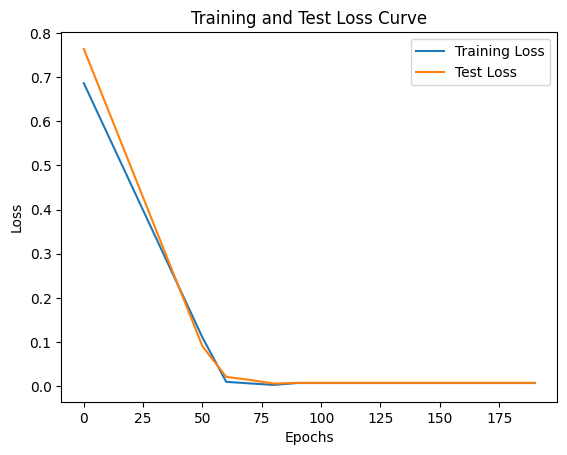

In [ ]:
## plot the loss curve
plt.plot(epoch_count,train_loss_values,label = "Training Loss")
plt.plot(epoch_count,test_loss_values,label = "Test Loss")
plt.title("Training and Test Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

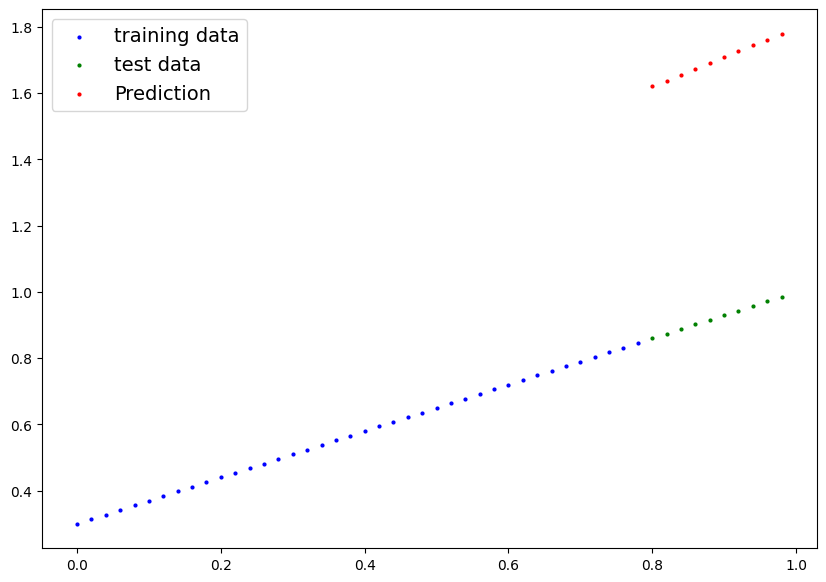

In [ ]:
plot_prediction(predictions = y_preds)

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)
y_preds_new

tensor([[0.8661],
        [0.8801],
        [0.8940],
        [0.9080],
        [0.9220],
        [0.9359],
        [0.9499],
        [0.9638],
        [0.9778],
        [0.9917]])

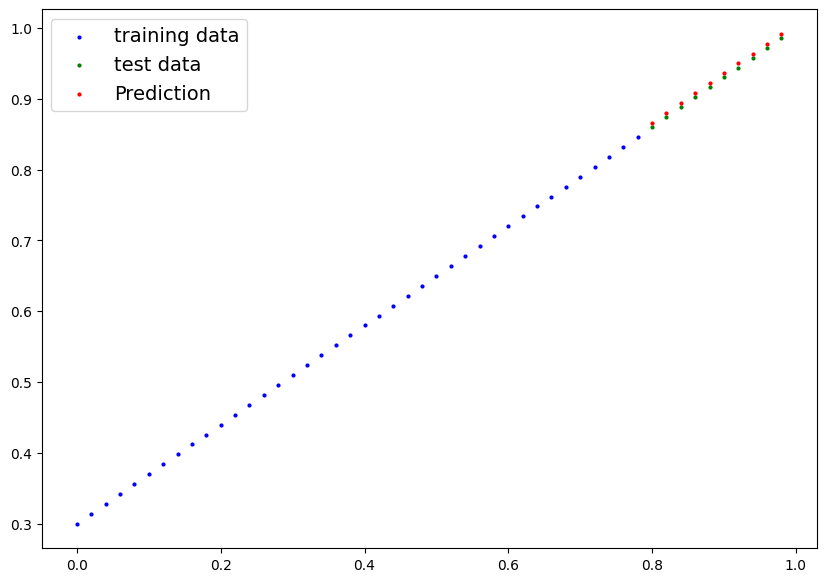

In [ ]:
plot_prediction(predictions=y_preds_new)

In [ ]:
#saving a model in pytorch
from pathlib import Path

#1. Create modls directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents = True, exist_ok = True)

#2. Create model save path
MODEL_NAME = '01_pytorch_workflow.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3SAVING THE MODEL
print(f"Saving model to : {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f = MODEL_SAVE_PATH,)

Saving model to : models/01_pytorch_workflow.pth


In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 1989 Jul 13 09:18 01_pytorch_workflow.pth


In [ ]:
#Loading the model
model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [ ]:
loaded_model_0 = LinearRegressionModule()
loaded_model_0.load_state_dict(torch.load(f = MODEL_SAVE_PATH))


<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [ ]:
#make some prediction with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)
loaded_model_preds

tensor([[0.8661],
        [0.8801],
        [0.8940],
        [0.9080],
        [0.9220],
        [0.9359],
        [0.9499],
        [0.9638],
        [0.9778],
        [0.9917]])

In [ ]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.8661],
        [0.8801],
        [0.8940],
        [0.9080],
        [0.9220],
        [0.9359],
        [0.9499],
        [0.9638],
        [0.9778],
        [0.9917]])

In [ ]:
#compare loaded model preds with original model preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [ ]:
#### Putting it together
import torch
from torch import nn
import matplotlib.pyplot as plt



In [ ]:
## device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"using device: {device}")

using device: cuda


In [ ]:
## create some data
weight = 0.7
bias = 0.3

#create range value
start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim = 1)
y = weight * X + bias

X[:10], y[:10]




(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
##spliting the data
train_split = int(0.8 * len(X))
X_train ,y_train = X[:train_split],y[:train_split]
X_test , y_test = X[train_split:],y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

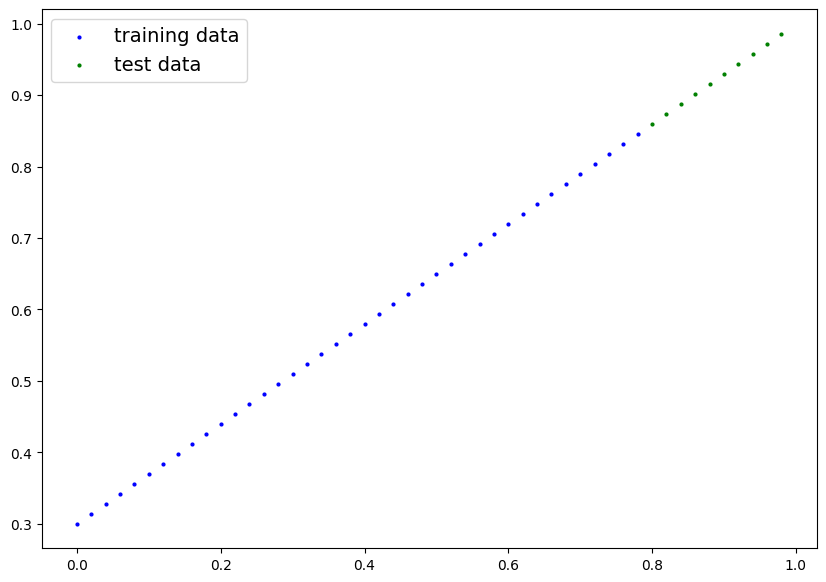

In [ ]:
#plot the data
plot_prediction(X_train,y_train,X_test,y_test)

In [ ]:
### building a pytorch linear model
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    #use nn.Linear() for creating the model parameters
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  #forword method
  def forward(self,x : torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

#set the manual seed
torch.manual_seed(42)

model_1 = LinearRegressionModelV2()
model_1 , model_1.state_dict()


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
#chceck the model current deviec
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
##training code
#loss fn
loss_fn = nn.L1Loss()
#optimizer
optimizer  = torch.optim.SGD(params = model_1.parameters(),lr = 0.1,)

In [ ]:
torch.manual_seed(42)
epochs = 200
#put data on the same device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)
for epoch in range(epochs):
  model_1.train()
  y_pred = model_1(X_train)
  loss = loss_fn(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  #testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred,y_test)

  #print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} |  Loss: {loss} | test loss: {test_loss}")

Epoch: 0 |  Loss: 0.5551779270172119 | test loss: 0.4527371823787689
Epoch: 10 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 20 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 30 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 40 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 50 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 60 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 70 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 80 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 90 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 100 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 110 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 120 |  Loss: 0.05761389806866646 | test loss: 0.11862673610448837
Epoch: 130 |  Loss: 0.05761389806866646 | test loss: 0.118626736

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6169]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3900], device='cuda:0'))])

In [ ]:
#making and evaluating predictions
model_1.eval()
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8836],
        [0.8959],
        [0.9082],
        [0.9206],
        [0.9329],
        [0.9453],
        [0.9576],
        [0.9699],
        [0.9823],
        [0.9946]], device='cuda:0')

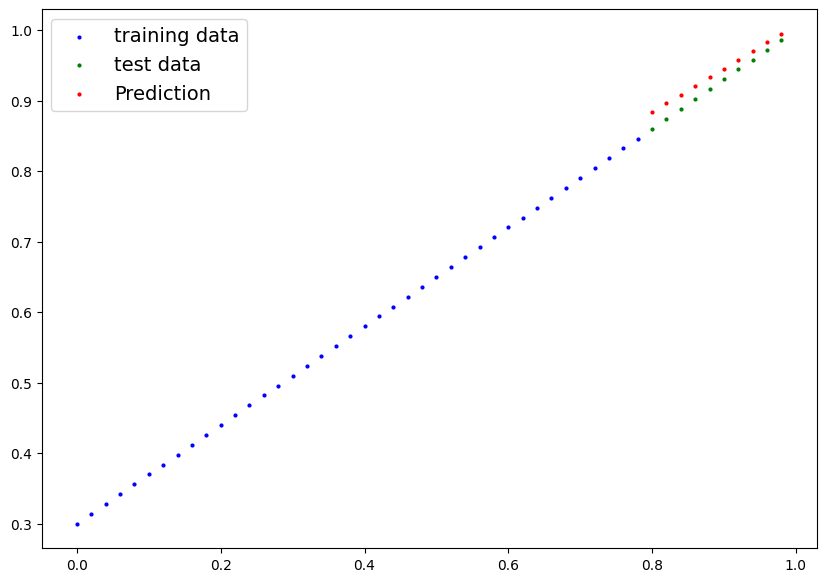

In [ ]:
#check out the model predictions visually
plot_prediction(predictions=y_preds.cpu())

In [ ]:
#saving a model
from pathlib import Path
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents = True, exist_ok = True)
MODEL_NAME = '01_pytorch_workflow.pth'
MODEL_SAVE_PATH = MODEL_PATH /  MODEL_NAME
print(f"Saved model in : {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(),f = MODEL_SAVE_PATH)

Saved model in : models/01_pytorch_workflow.pth


In [ ]:
#load models
loaded_model1 = LinearRegressionModelV2()
loaded_model1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model1.to(device)
print(f"Loaded model:\n{loaded_model1}")
print(f"Model on device:\n{next(loaded_model1.parameters()).device}")

Loaded model:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
cuda:0


In [ ]:
# Evaluate loaded model
loaded_model1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')